In [12]:
import numpy as np
from scipy.stats import norm, truncnorm
from scipy.integrate import tplquad, quad
import matplotlib.pyplot as plt
import time
from functools import lru_cache

# --- 参数定义 ---
# 正态分布参数
mean = 0
std_dev = 120

# 矩形尺寸
length = 100
width = 20
height = 25
half_length = length / 2
half_width = width / 2
half_height = height / 2

# Z方向参数
h0 = 150
sigma_z = 40
l = 120
a = (l - h0) / sigma_z
b = np.inf

# 积分球体半径
R = 20

# --- 定义概率密度函数 ---
# X, Y方向的概率计算函数
rv_norm_x = norm(loc=mean, scale=std_dev)
rv_norm_y = norm(loc=mean, scale=std_dev)

prob_x = lambda x: rv_norm_x.cdf(x + half_length) - rv_norm_x.cdf(x - half_length)
prob_y = lambda y: rv_norm_y.cdf(y + half_width) - rv_norm_y.cdf(y - half_width)

@lru_cache(maxsize=None)
def prob_xy_0_cached(x0, y0):
    return prob_x(x0) * prob_y(y0) / (width * length)

@lru_cache(maxsize=None)  
def probx_cached(x):
    return rv_norm_x.pdf(x)

@lru_cache(maxsize=None)  
def proby_cached(y):
    return rv_norm_y.pdf(y)

# Z方向的概率计算函数
rv_trunc_1 = truncnorm(a=a, b=b, loc=h0, scale=sigma_z)
rv_trunc_2 = truncnorm(a=a, b=b, loc=h0 + half_height, scale=sigma_z)

@lru_cache(maxsize=None)
def probz_cached(z):
    return rv_trunc_1.pdf(z)

@lru_cache(maxsize=None)
def prob_z_2_cached(z):
    return rv_trunc_2.pdf(z)

# 保留原始函数以便兼容
probx = probx_cached
proby = proby_cached
probz = probz_cached

prob_z_2_pdf = prob_z_2_cached

# 预计算 prob_x(0) 和 prob_y(0) 的常数值
prob_x_0 = prob_x(0)
prob_y_0 = prob_y(0)
prob_xy_0 = prob_x_0 * prob_y_0

probx_0 = probx(0)
proby_0 = proby(0)
probxy_0 = probx_0 * proby_0

In [22]:
from scipy.integrate import nquad

epsabs = 1e-10 # 降低绝对误差容限
epsrel = 1e-2  # 降低相对误差容限

def get_volume1(x0, y0, z0, idx):
    # 被积函数为 Pz(z) * Area(z), 其中 Area(z) 是z高度上球体横切面圆的面积
    integrand = lambda x,y,z: probx(x) * proby(y) * probz(z)
    result = integrate_over_minkowski_sum(integrand, x0, y0, z0, idx)
    
    return result

def integrate_over_minkowski_sum(target_func, x0, y0, z0, idx):
    """
    直接使用距离函数定义闵可夫斯基和的积分域
    """
    # 定义积分域：所有距离长方体不超过R的点
    def is_in_minkowski_sum(idx, x, y, z):
        # 计算点(x,y,z)到长方体的距离
        # 长方体中心在(0,0,z0)，尺寸为length×width×height
        if idx == 1:
            # 计算到长方体的距离
            dx = max(0, abs(x - x0) - half_length)
            dy = max(0, abs(y - y0) - half_width) 
            dz = max(0, abs(z - z0) - half_height)
            distance = (dx**2 + dy**2 + dz**2)
            return distance <= R**2
        
        elif idx == 2 or idx == 3:
            dx0 = max(0, abs(x - 0) - half_length)
            dy0 = max(0, abs(y - 0) - half_width)
            dx = max(0, abs(x - x0) - half_length)
            dy = max(0, abs(y - y0) - half_width) 
            dz = max(0, abs(z - z0) - half_height)
            distance_3_0 = (dx0**2 + dy0**2 + dz**2)
            distance_3 = (dx**2 + dy**2 + dz**2)
            return (distance_3_0 > R**2 and distance_3 <= R**2)
        
        elif idx == 4:
            dx0 = max(0, abs(x - 0) - half_length)
            dy0 = max(0, abs(y - 0) - half_width)
            dx = max(0, abs(x - x0) - half_length)
            dy = max(0, abs(y - y0) - half_width) 
            dz = max(0, abs(z - z0) - half_height)
            distance_3_0 = (dx0**2 + dy0**2 + dz**2)
            distance_3_1 = (dx0**2 + dy**2 + dz**2)
            distance_3_2 = (dx**2 + dy0**2 + dz**2)
            distance_3 = (dx**2 + dy**2 + dz**2)
            return (distance_3_0 > R**2 and distance_3_1 > R**2 and distance_3_2 > R**2 and distance_3 <= R**2)
        
    
    # 定义被积函数
    def integrand_with_domain1(x, y, z):
        if is_in_minkowski_sum(1, x, y, z):
            return target_func(x, y, z)
        else:
            return 0.0
        
    def integrand_with_domain2(x, y, z):
        if is_in_minkowski_sum(2, x, y, z):
            return target_func(x, y, z)
        else:
            return 0.0
        
    def integrand_with_domain3(x, y, z):
        if is_in_minkowski_sum(3, x, y, z):
            return target_func(x, y, z)
        else:
            return 0.0
        
    def integrand_with_domain4(x, y, z):
        if is_in_minkowski_sum(4, x, y, z):
            return target_func(x, y, z)
        else:
            return 0.0

    # 确定积分边界
    x_min, x_max = x0 - half_length - R, x0 + half_length + R
    y_min, y_max = y0 - half_width - R, y0 + half_width + R
    z_min, z_max = z0 - half_height - R, z0 + half_height + R
    
    # 使用nquad进行积分
    if idx == 1:
        result, _ = nquad(integrand_with_domain1, 
                      [[x_min, x_max], [y_min, y_max], [z_min, z_max]],  opts={'epsabs': epsabs, 'epsrel': epsrel})
    elif idx == 2:
        result, _ = nquad(integrand_with_domain2, 
                          [[x_min, x_max], [y_min, y_max], [z_min, z_max]],  opts={'epsabs': epsabs, 'epsrel': epsrel})
    elif idx == 3:
        result, _ = nquad(integrand_with_domain3, 
                          [[x_min, x_max], [y_min, y_max], [z_min, z_max]],  opts={'epsabs': epsabs, 'epsrel': epsrel})
    elif idx == 4:
        result, _ = nquad(integrand_with_domain4, 
                          [[x_min, x_max], [y_min, y_max], [z_min, z_max]],  opts={'epsabs': epsabs, 'epsrel': epsrel})
    
    return result
    
def get_volume2(x0, y0, z0):
    x_min_, x_max_ = x0 - half_length, x0 + half_length
    y_min_, y_max_ = y0 - half_width, y0 + half_width
    z_min_, z_max_ = 0, z0 - half_height - R
    integrand = lambda x,y,z: probx(x) * proby(y) * probz(z)
    result, _ = nquad(integrand, 
                    [[x_min_, x_max_], [y_min_, y_max_], [z_min_, z_max_]],  opts={'epsabs': epsabs, 'epsrel': epsrel})
    return result

# 完整的目标函数 I(z0)
def objective_function(x0, y0, z0, idx):
    volume = get_volume1(x0, y0, z0, idx)
    volume2 = get_volume2(x0, y0, z0)
    return volume + volume2 

In [ ]:
# --- 验证积分域体积的正确性 ---
def verify_integration_volume():
    """验证闵可夫斯基和的积分域体积是否正确"""
    # 理论体积计算
    # 闵可夫斯基和 = 原长方体 + 6个面的扩展 + 12条边的圆柱 + 8个角的球
    volume_box = length * width * height
    volume_faces = 2 * R * (length * width + length * height + width * height)
    volume_edges = np.pi * R**2 * (length + width + height)
    volume_corners = 4/3 * np.pi * R**3
    expected_volume = volume_box + volume_faces + volume_edges + volume_corners
    
    # 用常数函数1测试积分
    print("正在计算闵可夫斯基和体积...")
    test_integrand = lambda x, y, z: 1.0
    computed_volume = integrate_over_minkowski_sum(test_integrand, 0, 0, 0, 1)
    
    print(f"理论总体积: {expected_volume:.2f}")
    print(f"计算总体积: {computed_volume:.2f}")
    print(f"相对误差: {abs(computed_volume - expected_volume) / expected_volume * 100:.4f}%")
    print()
    
    return expected_volume, computed_volume

# 执行验证
#verify_integration_volume()



In [ ]:
# --- 数值优化 ( vectorized ) ---
z0_values = np.linspace(155, 160, 20)

print("\n开始计算目标函数 (优化后)...")
start_time = time.time()

# 使用列表推导式快速计算所有z0值对应的目标函数值
i_values = np.array([objective_function(0, 0, z0, 1) for z0 in z0_values])

end_time = time.time()
print(f"计算耗时: {end_time - start_time:.4f} 秒")

# 寻找最大值
max_i = np.max(i_values)
optimal_z0 = z0_values[np.argmax(i_values)]

print(f"\n计算完成！")
print(f"最大目标函数值: {max_i:.10f}")
print(f"最优 z0 值: {optimal_z0:.12f}")

In [ ]:
# --- 结果可视化 ---
plt.figure(figsize=(10, 6))
plt.plot(z0_values, i_values, label='I(z0)')
plt.scatter([optimal_z0], [max_i], color='red', zorder=5, label=f'Optimal Point ({optimal_z0:.5f}, {max_i:.6f})')
plt.title("Objective Function vs. z0 (Optimized)")
plt.xlabel("z0")
plt.ylabel("I(z0) Value")
plt.grid(True)
plt.legend()
plt.show()

In [26]:
def objective_function_T3(a, b, z0):
    obj1 = objective_function(0, 0, z0, 1)
    #print(obj1)
    obj2 = objective_function(a, 0, z0, 2)
    #print(obj2)
    obj3 = objective_function(0, b, z0, 3)
    #print(obj3)
    obj4 = objective_function(a, b, z0, 4)
    #print(obj4)

    res = obj1 / 4 + obj2 / 2 + obj3 / 2 + obj4
    return res * 4

t3 = objective_function_T3(140, 60, 157.1271)  #相切

In [ ]:
start_time = time.time()

# a_values = np.linspace(100,160,10)
# b_values = np.linspace(20,60,8)
a_values = np.linspace(121,130,27)
b_values = np.linspace(57,62,13)

# 创建二维网格
A, B = np.meshgrid(a_values, b_values)
values = np.zeros_like(A)
print("\n开始计算目标函数...")
# 计算每个网格点的值
for i in range(len(a_values)):
    for j in range(len(b_values)):
        values[j, i] = objective_function_T3(a_values[i], b_values[j], 157.788)
        print(f"计算进度: {i}/{len(a_values)}")

end_time = time.time()
print(f"计算耗时: {end_time - start_time:.4f} 秒")

# 正确找到最优点
max_idx = np.unravel_index(np.argmax(values), values.shape)
max_value = values[max_idx]
optimal_a = a_values[max_idx[1]]
optimal_b = b_values[max_idx[0]]

print(f"\n计算完成！")

print(f"最大目标函数值: {max_value:.12f}")
print(f"最优 a 值: {optimal_a:.12f}")
print(f"最优 b 值: {optimal_b:.12f}")


开始计算目标函数...
计算进度: 0/27
计算进度: 0/27
计算进度: 0/27
计算进度: 0/27
计算进度: 0/27
计算进度: 0/27
计算进度: 0/27
计算进度: 0/27
计算进度: 0/27
计算进度: 0/27
计算进度: 0/27
计算进度: 0/27
计算进度: 0/27
计算进度: 1/27
计算进度: 1/27
计算进度: 1/27
计算进度: 1/27
计算进度: 1/27
计算进度: 1/27
计算进度: 1/27
计算进度: 1/27
计算进度: 1/27
计算进度: 1/27
计算进度: 1/27
计算进度: 1/27
计算进度: 1/27
计算进度: 2/27
计算进度: 2/27
计算进度: 2/27
计算进度: 2/27
计算进度: 2/27
计算进度: 2/27
计算进度: 2/27
计算进度: 2/27
计算进度: 2/27
计算进度: 2/27
计算进度: 2/27
计算进度: 2/27
计算进度: 2/27
计算进度: 3/27
计算进度: 3/27
计算进度: 3/27
计算进度: 3/27
计算进度: 3/27
计算进度: 3/27
计算进度: 3/27
计算进度: 3/27
计算进度: 3/27
计算进度: 3/27
计算进度: 3/27
计算进度: 3/27
计算进度: 3/27
计算进度: 4/27
计算进度: 4/27
计算进度: 4/27
计算进度: 4/27
计算进度: 4/27
计算进度: 4/27
计算进度: 4/27
计算进度: 4/27
计算进度: 4/27
计算进度: 4/27
计算进度: 4/27
计算进度: 4/27
计算进度: 4/27
计算进度: 5/27
计算进度: 5/27
计算进度: 5/27
计算进度: 5/27
计算进度: 5/27
计算进度: 5/27
计算进度: 5/27
计算进度: 5/27
计算进度: 5/27
计算进度: 5/27
计算进度: 5/27
计算进度: 5/27
计算进度: 5/27
计算进度: 6/27
计算进度: 6/27
计算进度: 6/27
计算进度: 6/27
计算进度: 6/27
计算进度: 6/27
计算进度: 6/27
计算进度: 6/27
计算进度: 6/27
计算进度: 6/27
计算进度: 6/27
计算进度: 6/

In [36]:
# res = objective_function_T3(140, 60, 157.788)
# print(res)

# 解决matplotlib中文显示乱码问题
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.font_manager import FontProperties
import platform

# 设置中文字体
def setup_chinese_font():
    """设置matplotlib中文字体"""
    system = platform.system()
    
    if system == "Windows":
        # Windows系统常用中文字体
        font_candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    elif system == "Darwin":  # macOS
        font_candidates = ['Arial Unicode MS', 'Heiti TC', 'PingFang SC']
    else:  # Linux
        font_candidates = ['WenQuanYi Micro Hei', 'DejaVu Sans']
    
    for font_name in font_candidates:
        try:
            # 测试字体是否可用
            plt.rcParams['font.sans-serif'] = [font_name]
            plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
            
            # 测试绘图
            fig, ax = plt.subplots(figsize=(1, 1))
            ax.text(0.5, 0.5, '测试中文', fontsize=12, ha='center')
            plt.close(fig)
            
            print(f"成功设置中文字体: {font_name}")
            return True
        except:
            continue
    
    print("警告: 未找到合适的中文字体，可能仍会出现乱码")
    return False

# 运行字体设置
setup_chinese_font()

# 显示当前字体设置
print(f"当前字体设置: {plt.rcParams['font.sans-serif']}")
print(f"负号显示设置: {plt.rcParams['axes.unicode_minus']}")


成功设置中文字体: SimHei
当前字体设置: ['SimHei']
负号显示设置: False


In [ ]:
# --- 结果可视化 ---
plt.figure(figsize=(12, 8))

# 创建3D图
from mpl_toolkits.mplot3d import Axes3D
ax = plt.axes(projection='3d')

# 绘制3D表面
surf = ax.plot_surface(A, B, values, cmap='viridis', alpha=0.7)

# 标记最优点
ax.scatter([optimal_a], [optimal_b], [max_value], color='red', s=50, alpha=1.0,
          label=f'最优点\na = {optimal_a:.4f}m\nb = {optimal_b:.4f}m\nI = {max_value:.5f}')

ax.set_xlabel("a/m", fontsize=20)
ax.set_ylabel("b/m", fontsize=20)
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()

# 绘制等高线图
plt.figure(figsize=(10, 6))
contour = plt.contour(A, B, values, levels=20)
plt.clabel(contour, inline=True, fontsize=8)
plt.scatter([optimal_a], [optimal_b], color='red', s=50, zorder=5, 
           label=f'最优点({optimal_a:.4f}, {optimal_b:.4f})')
plt.xlabel("a/m", fontsize=20)
plt.ylabel("b/m", fontsize=20)
plt.grid(True)
plt.legend(fontsize=14, loc='upper right')
plt.colorbar(contour)
plt.show()


In [49]:
start_time = time.time()

# --- 数值优化 ( vectorized ) ---
a_values = np.linspace(100,160,10)
b_values = np.linspace(20,60,8)

# 创建二维网格
A, B = np.meshgrid(a_values, b_values)
values = np.zeros_like(A)
print("\n开始计算目标函数...")
# 计算每个网格点的值
for i in range(len(a_values)):
    for j in range(len(b_values)):
        values[j, i] = objective_function_T3(a_values[i], b_values[j], 157.788)
        print(f"计算进度: {i}/{len(a_values)}")

end_time = time.time()
print(f"计算耗时: {end_time - start_time:.4f} 秒")

# 正确找到最优点
max_idx = np.unravel_index(np.argmax(values), values.shape)
max_value = values[max_idx]
optimal_a = a_values[max_idx[1]]
optimal_b = b_values[max_idx[0]]

print(f"\n计算完成！")

print(f"最大目标函数值: {max_value:.12f}")
print(f"最优 a 值: {optimal_a:.12f}")
print(f"最优 b 值: {optimal_b:.12f}")


开始计算目标函数...
计算进度: 0/10
计算进度: 0/10
计算进度: 0/10
计算进度: 0/10
计算进度: 0/10
计算进度: 0/10
计算进度: 0/10
计算进度: 0/10
计算进度: 1/10
计算进度: 1/10
计算进度: 1/10
计算进度: 1/10
计算进度: 1/10
计算进度: 1/10
计算进度: 1/10
计算进度: 1/10
计算进度: 2/10
计算进度: 2/10
计算进度: 2/10
计算进度: 2/10
计算进度: 2/10
计算进度: 2/10
计算进度: 2/10
计算进度: 2/10
计算进度: 3/10
计算进度: 3/10
计算进度: 3/10
计算进度: 3/10
计算进度: 3/10
计算进度: 3/10
计算进度: 3/10
计算进度: 3/10
计算进度: 4/10
计算进度: 4/10
计算进度: 4/10
计算进度: 4/10
计算进度: 4/10
计算进度: 4/10
计算进度: 4/10
计算进度: 4/10
计算进度: 5/10
计算进度: 5/10
计算进度: 5/10
计算进度: 5/10
计算进度: 5/10
计算进度: 5/10
计算进度: 5/10
计算进度: 5/10
计算进度: 6/10
计算进度: 6/10
计算进度: 6/10
计算进度: 6/10
计算进度: 6/10
计算进度: 6/10
计算进度: 6/10
计算进度: 6/10
计算进度: 7/10
计算进度: 7/10
计算进度: 7/10
计算进度: 7/10
计算进度: 7/10
计算进度: 7/10
计算进度: 7/10
计算进度: 7/10
计算进度: 8/10
计算进度: 8/10
计算进度: 8/10
计算进度: 8/10
计算进度: 8/10
计算进度: 8/10
计算进度: 8/10
计算进度: 8/10
计算进度: 9/10
计算进度: 9/10
计算进度: 9/10
计算进度: 9/10
计算进度: 9/10
计算进度: 9/10
计算进度: 9/10
计算进度: 9/10
计算耗时: 15522.5818 秒

计算完成！
最大目标函数值: 0.329521622024
最优 a 值: 126.666666666667
最优 b 值: 60.000000000000


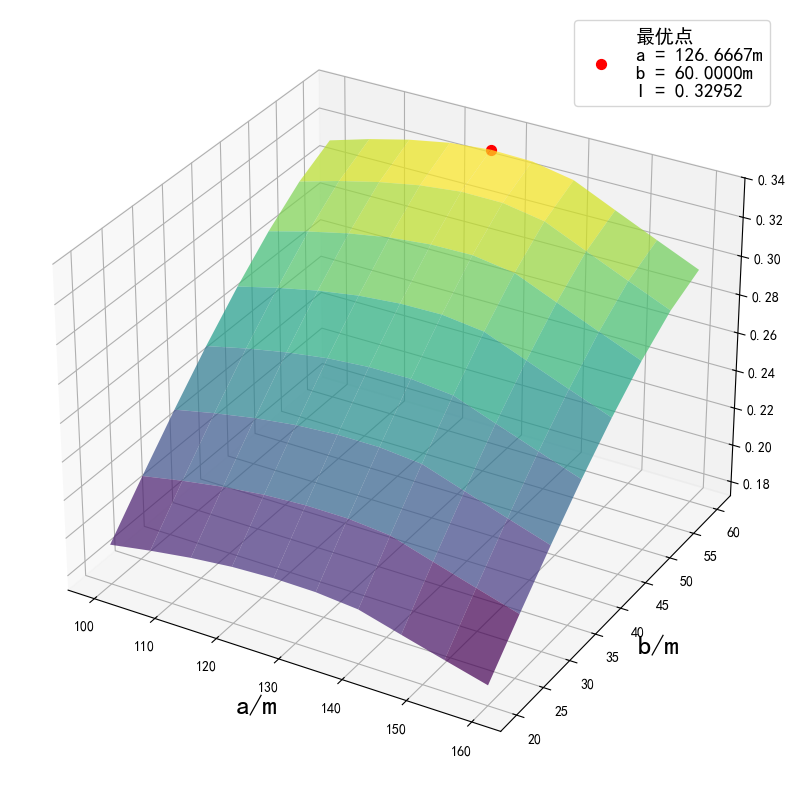

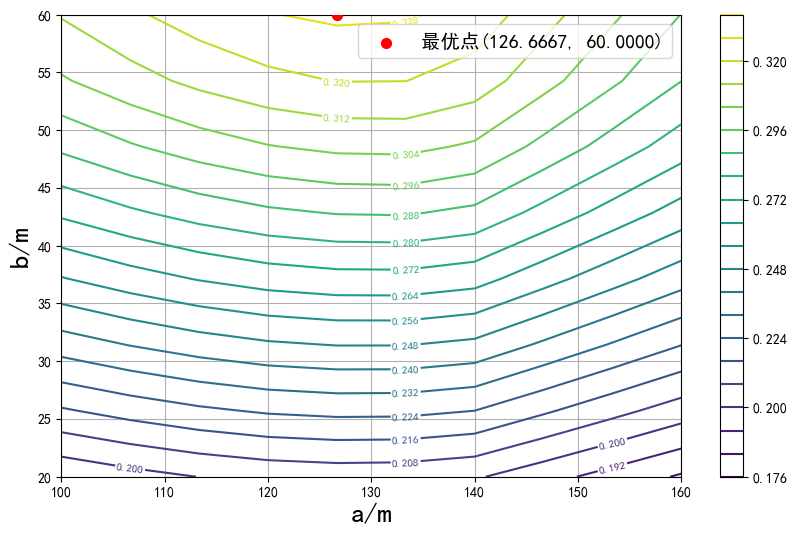

In [50]:
# --- 结果可视化 ---
plt.figure(figsize=(12, 8))

# 创建3D图
from mpl_toolkits.mplot3d import Axes3D
ax = plt.axes(projection='3d')

# 绘制3D表面
surf = ax.plot_surface(A, B, values, cmap='viridis', alpha=0.7)

# 标记最优点
ax.scatter([optimal_a], [optimal_b], [max_value], color='red', s=50, alpha=1.0,
          label=f'最优点\na = {optimal_a:.4f}m\nb = {optimal_b:.4f}m\nI = {max_value:.5f}')

#ax.set_title("Objective Function I(a,b) vs. a and b")
ax.set_xlabel("a/m", fontsize=20)
ax.set_ylabel("b/m", fontsize=20)
#ax.set_zlabel("概率", fontsize=16)
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()

# 也可以绘制等高线图
plt.figure(figsize=(10, 6))
contour = plt.contour(A, B, values, levels=20)
plt.clabel(contour, inline=True, fontsize=8)
plt.scatter([optimal_a], [optimal_b], color='red', s=50, zorder=5, 
           label=f'最优点({optimal_a:.4f}, {optimal_b:.4f})')
#plt.title("Objective Function Contour Plot")
plt.xlabel("a/m", fontsize=20)
plt.ylabel("b/m", fontsize=20)
plt.grid(True)
plt.legend(fontsize=14, loc='upper right')
plt.colorbar(contour)
plt.show()
